In [60]:
import torch
import numpy as np
import matplotlib.pyplot as plt

x.requires_grad = False
xx.requires_grad = False


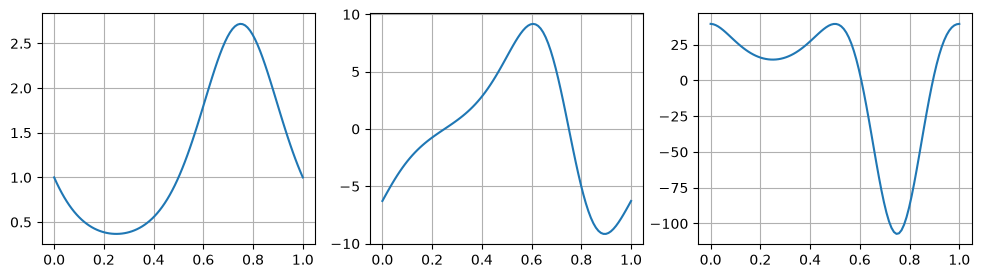

In [61]:
x = torch.linspace(0, 1, 100)
print(f"x.requires_grad = {x.requires_grad}")
def func(x):
    return torch.exp(-torch.sin(2*torch.pi * x))

def dfunc(x):
    return -2*torch.pi * torch.cos(2*torch.pi * x) * func(x)

def d2func(x):
    a1 = 4*torch.pi**2 * torch.sin(2*torch.pi * x)
    a2 = 4*torch.pi**2 * torch.cos(2*torch.pi * x) ** 2
    return (a1 + a2) * func(x)

print(f"xx.requires_grad = {x.requires_grad}")
plt.subplots(nrows=1,ncols=3, figsize=(12, 3))
plt.subplot(131), plt.plot(x, func(x)), plt.grid(True)
plt.subplot(132), plt.plot(x, dfunc(x)), plt.grid(True)
plt.subplot(133), plt.plot(x, d2func(x)), plt.grid(True)
plt.show()

In [62]:
# First derivative
x.requires_grad_(True)
u = func(x)
grad_u = torch.autograd.grad(
    u, x, grad_outputs=torch.ones_like(u),
    create_graph=True
)
print(type(grad_u))

grad_u = grad_u[0]
print(type(grad_u))

<class 'tuple'>
<class 'torch.Tensor'>


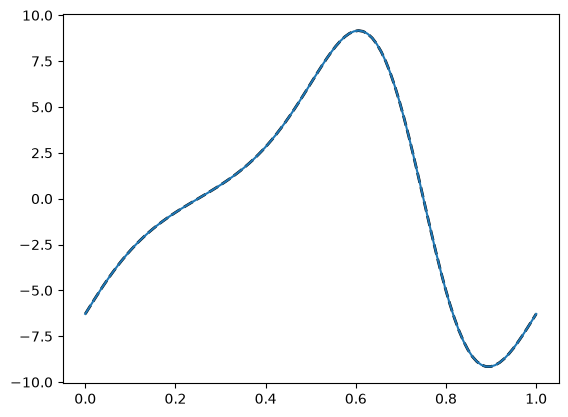

In [63]:
plt.plot(x.detach(), dfunc(x.detach()), 'k--', linewidth=2.0)
plt.plot(x.detach(), grad_u.detach())

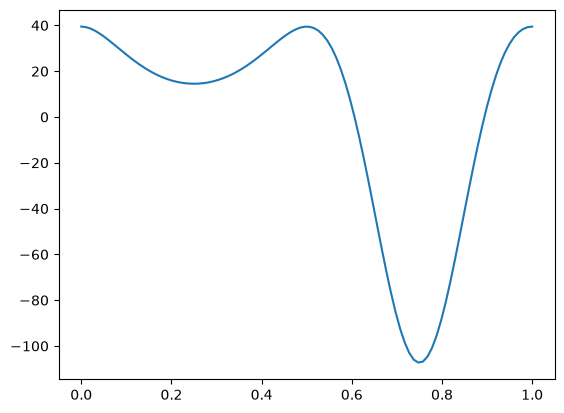

In [64]:
# Second derivative
grad_u_x = torch.autograd.grad(grad_u, x, grad_outputs=torch.ones_like(grad_u), create_graph=True)[0]
plt.plot(x.detach(), grad_u_x.detach())

# Scalar function of multiple variables

In [ ]:
x1 = torch.linspace(-1, 1, 20)
x2 = torch.linspace(-1, 1, 20)
X = torch.vstack((x1, x2)).T
def func(x):
    return torch.cos(2*torch.pi*x[:,0]) * torch.sin(2*torch.pi * x[:,1])

def dfunc(x):
    df_dx1 = -2*torch.pi * torch.sin()

X.requires_grad_(True)
u = func(X)

In [77]:
grad_u = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
print(f"grad_u.shape = {grad_u.shape}")

grad_u.shape = torch.Size([20, 2])


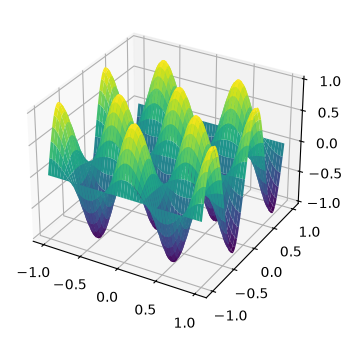

In [81]:
z1, z2 = torch.linspace(-1, 1, 250), torch.linspace(-1, 1, 250)
Z1, Z2 = torch.meshgrid(z1, z2, indexing='xy')
F = torch.cos(2*torch.pi*Z1) * torch.sin(2*torch.pi*Z2)
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Z1, Z2, F, cmap='viridis')

# Using `backward()`

In [73]:
x = torch.linspace(0, 1, 100, requires_grad=True)
f = func(x)
f.backward(torch.ones_like(x), retain_graph=True)
plt.plot(x.detach(), x.grad)

IndexError: too many indices for tensor of dimension 1

In [ ]:
x.grad.backward(torch.ones_like(x), retain_graph=True)
plt.plot(x.detach(), x.grad.grad)

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn